In [144]:
import os
import json
import humanize
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D

In [145]:
data = []
for fn in os.listdir("./projectile-data"):
  if fn.endswith(".json"):
    with open(f"./projectile-data/{fn}", "r") as f:
      raw = json.load(f)
      data += raw['data']

In [146]:
df = pd.json_normalize(data)
# df['position.x'] = df['position.x'].apply(lambda x: -x)
df['velocity_length'] = (df['velocity.x']**2 + df['velocity.y']**2 + df['velocity.z']**2)**0.5
df['energy'] = (df['ammo_properties.mass'] * df['velocity_length']**2) / 2
df

,distance,draw_frame,fragmentation_count,id,impact_count,penetration_count,physics_frame,ricochet_count,time,total_substeps,...,ammo_properties.drag_coef,ammo_properties.mass,position.x,position.y,position.z,velocity.x,velocity.y,velocity.z,velocity_length,energy
0,30.569000,1416,1,1415_1181_1415,1,0,1182,0,1.752517e+09,1,...,0.7,0.35,19.596695,1.961463,-23.272179,0.000833,420.349365,354.993500,550.194487,52974.945401
1,30.466953,1416,1,1415_1181_1415,1,0,1182,0,1.752517e+09,2,...,0.7,0.35,19.596695,2.136546,-23.124317,0.001666,420.199585,354.867676,549.998871,52937.282741
2,30.366327,1416,1,1415_1181_1415,1,0,1182,0,1.752517e+09,3,...,0.7,0.35,19.596695,2.311567,-22.976507,0.002499,420.049896,354.741943,549.803385,52899.658300
3,30.267138,1416,1,1415_1181_1415,1,0,1182,0,1.752517e+09,4,...,0.7,0.35,19.596697,2.486526,-22.828751,0.003332,419.900299,354.616302,549.608027,52862.072054
4,30.169397,1416,1,1415_1181_1415,1,0,1182,0,1.752517e+09,5,...,0.7,0.35,19.596699,2.661422,-22.681046,0.004164,419.750824,354.490753,549.412821,52824.528458
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1060,59.219028,1416,1,1415_1181_1415,1,0,1182,0,1.752517e+09,196,...,0.7,0.35,19.603247,43.598312,-35.205605,0.158051,495.159485,-139.592255,514.459851,46317.064147
1061,59.404987,1416,1,1415_1181_1415,1,0,1182,0,1.752517e+09,197,...,0.7,0.35,19.603313,43.804558,-35.263748,0.158832,494.994446,-139.545959,514.288442,46286.205246
1062,59.591072,1416,1,1415_1181_1415,1,0,1182,0,1.752517e+09,198,...,0.7,0.35,19.603380,44.010738,-35.321873,0.159612,494.829498,-139.499695,514.117129,46255.373974
1063,59.777283,1416,1,1415_1181_1415,1,0,1182,0,1.752517e+09,199,...,0.7,0.35,19.603447,44.216846,-35.379978,0.160393,494.664673,-139.453461,513.945943,46224.575599


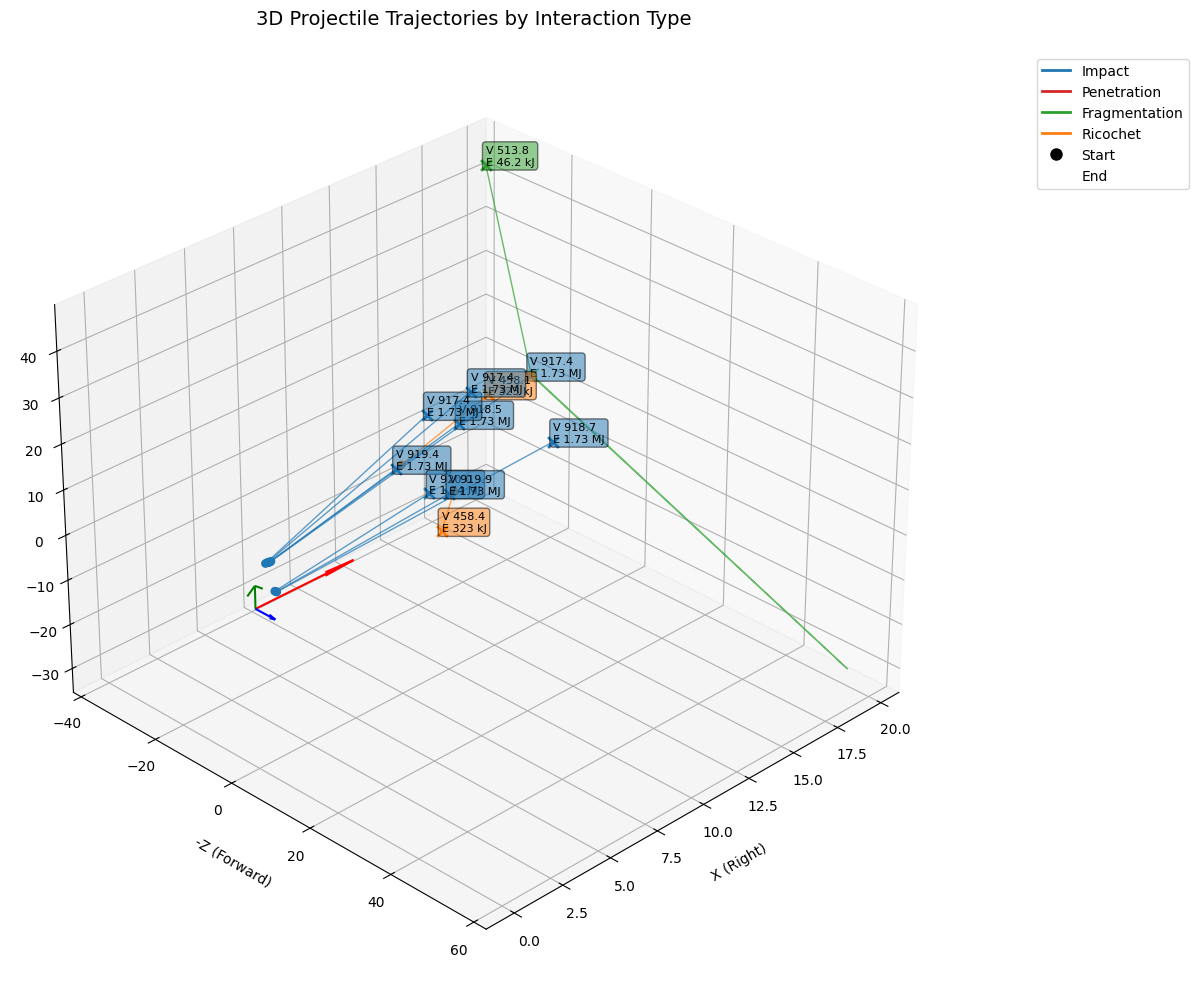

In [ ]:
# Сгруппируем данные по ID снаряда (если есть) или сгенерируем уникальные группы
if 'id' in df.columns:
  groups = df.groupby('id')
else:
  # Создаем искусственные группы по последовательности событий
  df['group_id'] = (df['physics_frame'].diff() > 1).cumsum()
  groups = df.groupby('group_id')

# Цветовая схема взаимодействий
interaction_colors = {
  'impact': '#1f77b4',      # Синий - обычное попадание
  'penetration': '#d62728', # Красный - пробитие
  'fragmentation': '#2ca02c', # Зеленый - фрагментация
  'ricochet': '#ff7f0e'     # Оранжевый - рикошет
}

# Определение координатных столбцов
x_col = 'position.x'
y_col = 'position.z' 
z_col = 'position.y'  # Высота

# Создаем 3D график
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')
# ax.set_box_aspect([1, 1, 1])


# Функция для определения типа взаимодействия
def get_interaction_type(group):
  last_row = group.iloc[-1]
  if last_row['penetration_count'] > 0:
    return 'penetration'
  elif last_row['fragmentation_count'] > 0:
    return 'fragmentation'
  elif last_row['ricochet_count'] > 0:
    return 'ricochet'
  else:
    return 'impact'

# Подготовка данных с типами
typed_groups = []
for name, group in groups:
  int_type = get_interaction_type(group)
  typed_groups.append((name, group, int_type))

# Отрисовка траекторий
for name, group, int_type in typed_groups:
  # Траектория
  ax.plot(group[x_col], group[y_col], group[z_col],
          color=interaction_colors[int_type],
          linewidth=1,
          zorder=20,
          alpha=0.7)
  
  # Начальная точка
  ax.scatter(group[x_col].iloc[0], group[y_col].iloc[0], group[z_col].iloc[0],
             color=interaction_colors[int_type],
             marker='o',
             s=40,
             edgecolor='none',
             zorder=50,
             depthshade=False)
  
  # Конечная точка
  ax.scatter(group[x_col].iloc[-1], group[y_col].iloc[-1], group[z_col].iloc[-1],
             color=interaction_colors[int_type],
             marker='x',
             s=60,
             linewidth=2,
             zorder=100,
             depthshade=False)

# Настройка легенды
legend_elements = [
  Line2D([0], [0], color=interaction_colors['impact'], lw=2, label='Impact'),
  Line2D([0], [0], color=interaction_colors['penetration'], lw=2, label='Penetration'),
  Line2D([0], [0], color=interaction_colors['fragmentation'], lw=2, label='Fragmentation'),
  Line2D([0], [0], color=interaction_colors['ricochet'], lw=2, label='Ricochet'),
  Line2D([0], [0], marker='o', color='w', label='Start',
         markerfacecolor='black', markersize=10),
  Line2D([0], [0], marker='x', color='w', label='End',
         markerfacecolor='black', markersize=10)
]

# Настройки графика
ax.set_title('3D Projectile Trajectories by Interaction Type', pad=20, fontsize=14)
ax.set_xlabel('X Position', fontsize=12, labelpad=10)
ax.set_ylabel('Z Position', fontsize=12, labelpad=10)
ax.set_zlabel('Y Position (Height)', fontsize=12, labelpad=10)
ax.legend(handles=legend_elements, bbox_to_anchor=(1.1, 1), loc='upper left')
ax.grid(True, alpha=0.2)

# Добавление аннотаций
for name, group, int_type in typed_groups:
  last_row = group.iloc[-1]
  info_text = ''
  # info_text = f"I:{last_row['impact_count']}"
  # if last_row['penetration_count'] > 0:
  #   info_text += f" P:{last_row['penetration_count']}"
  # if last_row['fragmentation_count'] > 0:
  #   info_text += f" F:{last_row['fragmentation_count']}"
  # if last_row['ricochet_count'] > 0:
  #   info_text += f" R:{last_row['ricochet_count']}"
  info_text += f"V {round(last_row['velocity_length'], 1)}"
  info_text += f"\nE {humanize.metric(last_row['energy'])}J"
  
  ax.text(last_row[x_col], last_row[y_col], last_row[z_col],
          info_text,
          fontsize=8,
          bbox=dict(boxstyle='round,pad=0.3',
                   fc=interaction_colors[int_type],
                   alpha=0.5),
          zorder=1000)


ax.invert_yaxis()

# Настройка подписей
ax.set_xlabel('X (Right)', fontsize=10)
ax.set_ylabel('-Z (Forward)', fontsize=10)
ax.set_zlabel('Y (Up)', fontsize=10)

# Угол обзора по умолчанию как в Godot
ax.view_init(elev=30, azim=225)  # Наклон сверху-спереди
# Оси координат (красный-X, зеленый-Y, синий-Z)
ax.quiver(0, 0, 0, 1, 0, 0, color='r', length=5)
ax.quiver(0, 0, 0, 0, 1, 0, color='b', length=5) 
ax.quiver(0, 0, 0, 0, 0, 1, color='g', length=5)

plt.tight_layout()
plt.show()